# 02 — Exploratory Data Analysis

This notebook explores the reconstructed UK housing dataset before model development.

The analysis is designed around a **one-month-ahead forecasting problem**. It distinguishes between descriptive relationships in the historical master dataset, information available at the forecast origin, the next-month price target, and short-term price movement.

The goal is to understand the data structure, identify potentially useful signals, detect redundancy and multicollinearity, and avoid misleading conclusions caused by trend or target leakage.

> **Important:** correlations in this notebook are descriptive associations, not evidence of causality.

## 1. Imports and project paths

The notebook uses the same repository structure as Notebook 01 and reads only the processed datasets created during the reconstruction stage.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.stats.outliers_influence import variance_inflation_factor

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

MASTER_PATH = PROCESSED_DIR / "uk_housing_master_2009_2023.csv"
MODEL_PATH = PROCESSED_DIR / "uk_housing_modelling_base.csv"

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Project root:", PROJECT_ROOT)
print("Master dataset:", MASTER_PATH)
print("Modelling dataset:", MODEL_PATH)

Project root: /mnt/data/eda_project
Master dataset: /mnt/data/eda_project/data/processed/uk_housing_master_2009_2023.csv
Modelling dataset: /mnt/data/eda_project/data/processed/uk_housing_modelling_base.csv


## 2. Load and validate the datasets

The master dataset contains the reconstructed monthly historical series. The modelling dataset contains leakage-aware lagged features and the next-month target created in Notebook 01.

In [2]:
master = pd.read_csv(MASTER_PATH, parse_dates=["date"])
model = pd.read_csv(MODEL_PATH, parse_dates=["forecast_origin", "target_date"])

assert len(master) == 172
assert master["date"].min() == pd.Timestamp("2009-01-01")
assert master["date"].max() == pd.Timestamp("2023-04-01")
assert master["date"].is_monotonic_increasing
assert not master["date"].duplicated().any()

assert len(model) == 160
assert model["forecast_origin"].is_monotonic_increasing
assert not model.isna().any().any()

print(f"Master dataset: {master.shape[0]} rows × {master.shape[1]} columns")
print(f"Master period: {master['date'].min().date()} to {master['date'].max().date()}")
print(f"Modelling dataset: {model.shape[0]} rows × {model.shape[1]} columns")
print(f"Forecast target period: {model['target_date'].min().date()} to {model['target_date'].max().date()}")

Master dataset: 172 rows × 11 columns
Master period: 2009-01-01 to 2023-04-01
Modelling dataset: 160 rows × 17 columns
Forecast target period: 2010-01-01 to 2023-04-01


## 3. Data quality and descriptive statistics

Before interpreting relationships, confirm that the reconstructed tables are structurally complete and inspect the scale and variability of each series.

In [3]:
missing_master = master.isna().sum()
missing_model = model.isna().sum()

print("Missing cells in master dataset:", int(missing_master.sum()))
print("Missing cells in modelling dataset:", int(missing_model.sum()))

pd.DataFrame({"missing_values": missing_master}).sort_values("missing_values", ascending=False)

Missing cells in master dataset: 0
Missing cells in modelling dataset: 0


,missing_values
date,0
average_house_price_gbp,0
house_price_12m_change_pct,0
sales_volume,0
sales_volume_source,0
average_weekly_earnings_gbp,0
unemployment_rate_pct,0
cpi_annual_rate_pct,0
gdp_monthly_growth_pct,0
public_sector_net_borrowing_ex_banks_gbp_mn,0


In [4]:
numeric_master = master.select_dtypes(include="number")
numeric_master.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]

,mean,std,min,25%,50%,75%,max
average_house_price_gbp,"208,800.572","38,579.410","154,452.381","170,325.309","206,611.287","231,818.647","292,981.950"
house_price_12m_change_pct,3.609,5.148,-15.619,1.073,4.331,7.126,14.232
sales_volume,"76,424.246","19,365.247","28,356.333","65,520.000","75,311.667","89,264.750","165,290.000"
average_weekly_earnings_gbp,503.919,55.678,409.000,461.000,489.500,537.500,651.000
unemployment_rate_pct,5.720,1.689,3.500,4.100,5.100,7.800,8.500
cpi_annual_rate_pct,2.809,2.449,-0.100,1.500,2.400,3.200,11.100
gdp_monthly_growth_pct,0.140,2.036,-20.900,-0.025,0.200,0.500,9.000
public_sector_net_borrowing_ex_banks_gbp_mn,"9,695.209","8,177.784","-12,570.000","5,859.750","9,409.500","12,897.250","51,405.000"
bank_rate_month_end_pct,0.618,0.677,0.100,0.500,0.500,0.500,4.250


## 4. UK house-price trend

House prices are strongly trending over the study period. This matters because two unrelated variables can appear highly correlated when both trend through time.

The level series is useful for forecasting, but correlations with the level target must therefore be interpreted cautiously.

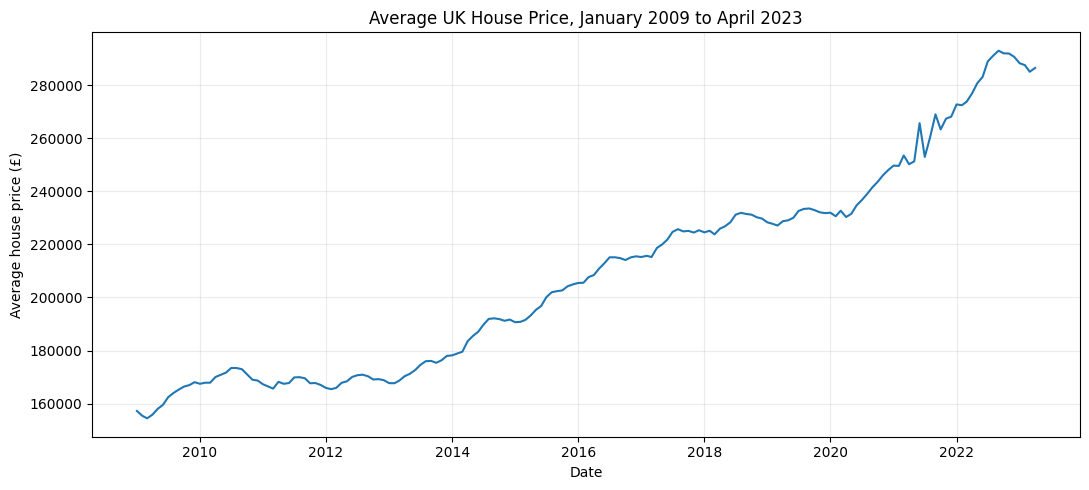

January 2009 average price: £157,234
April 2023 average price: £286,489
Change across the study period: 82.2%


In [5]:
plt.figure(figsize=(11, 5))
plt.plot(master["date"], master["average_house_price_gbp"])
plt.title("Average UK House Price, January 2009 to April 2023")
plt.xlabel("Date")
plt.ylabel("Average house price (£)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

start_price = master.loc[0, "average_house_price_gbp"]
end_price = master.loc[master.index[-1], "average_house_price_gbp"]
overall_change = (end_price / start_price - 1) * 100

print(f"January 2009 average price: £{start_price:,.0f}")
print(f"April 2023 average price: £{end_price:,.0f}")
print(f"Change across the study period: {overall_change:.1f}%")

## 5. Annual house-price growth and market volatility

The annual growth rate helps separate changes in market momentum from the long-run price level.

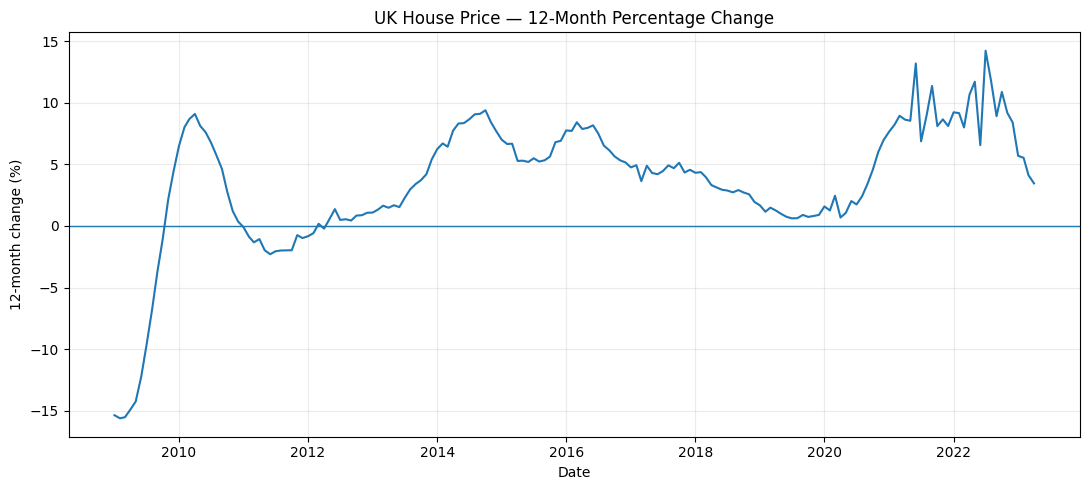

Minimum annual change: -15.62%
Maximum annual change: 14.23%
Mean annual change: 3.61%


In [6]:
plt.figure(figsize=(11, 5))
plt.plot(master["date"], master["house_price_12m_change_pct"])
plt.axhline(0, linewidth=1)
plt.title("UK House Price — 12-Month Percentage Change")
plt.xlabel("Date")
plt.ylabel("12-month change (%)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

growth = master["house_price_12m_change_pct"]
print(f"Minimum annual change: {growth.min():.2f}%")
print(f"Maximum annual change: {growth.max():.2f}%")
print(f"Mean annual change: {growth.mean():.2f}%")

## 6. Key economic indicators through time

Each indicator is shown separately so its scale and turning points remain readable.

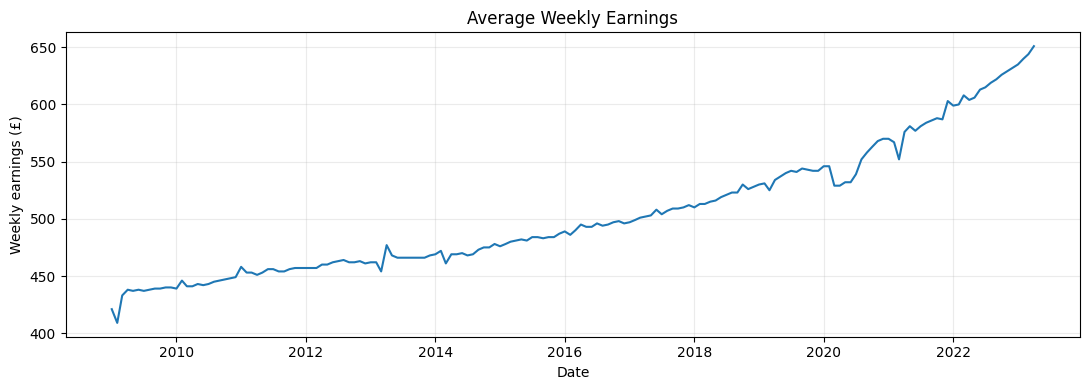

In [7]:
plt.figure(figsize=(11, 4))
plt.plot(master["date"], master["average_weekly_earnings_gbp"])
plt.title("Average Weekly Earnings")
plt.xlabel("Date")
plt.ylabel("Weekly earnings (£)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

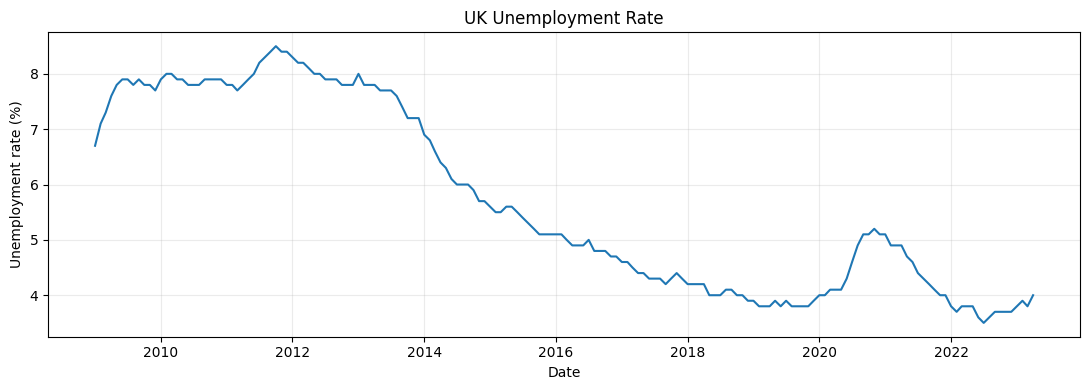

In [8]:
plt.figure(figsize=(11, 4))
plt.plot(master["date"], master["unemployment_rate_pct"])
plt.title("UK Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Unemployment rate (%)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

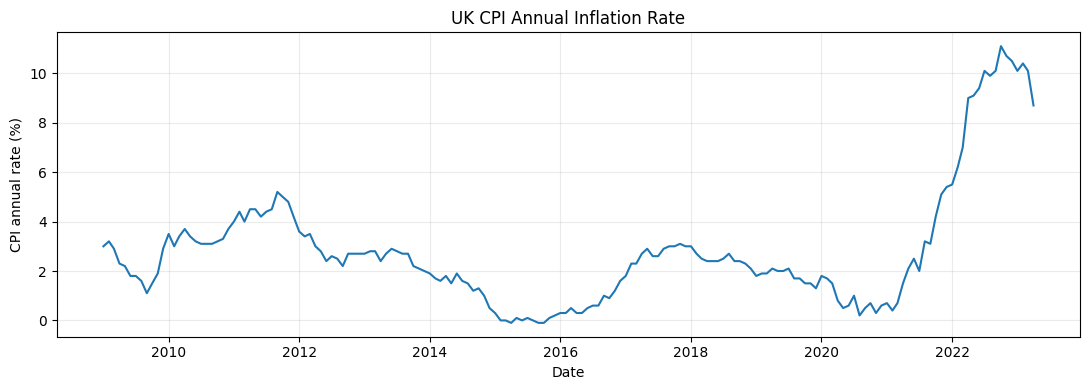

In [9]:
plt.figure(figsize=(11, 4))
plt.plot(master["date"], master["cpi_annual_rate_pct"])
plt.title("UK CPI Annual Inflation Rate")
plt.xlabel("Date")
plt.ylabel("CPI annual rate (%)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

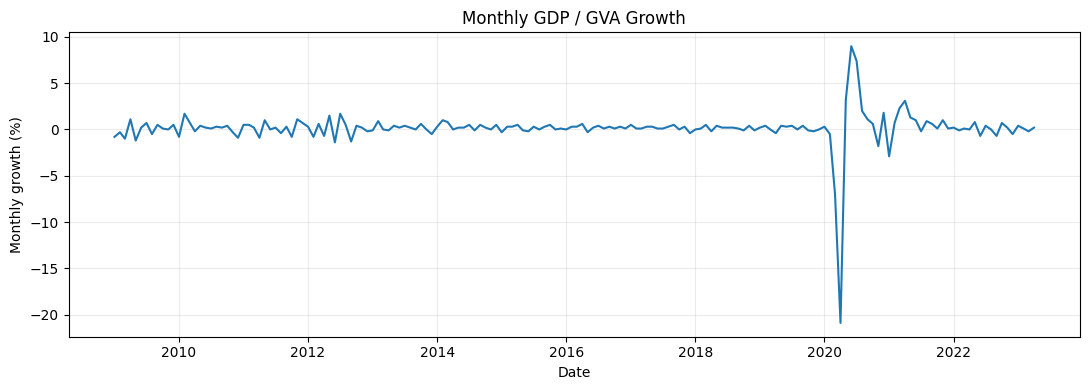

In [10]:
plt.figure(figsize=(11, 4))
plt.plot(master["date"], master["gdp_monthly_growth_pct"])
plt.title("Monthly GDP / GVA Growth")
plt.xlabel("Date")
plt.ylabel("Monthly growth (%)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

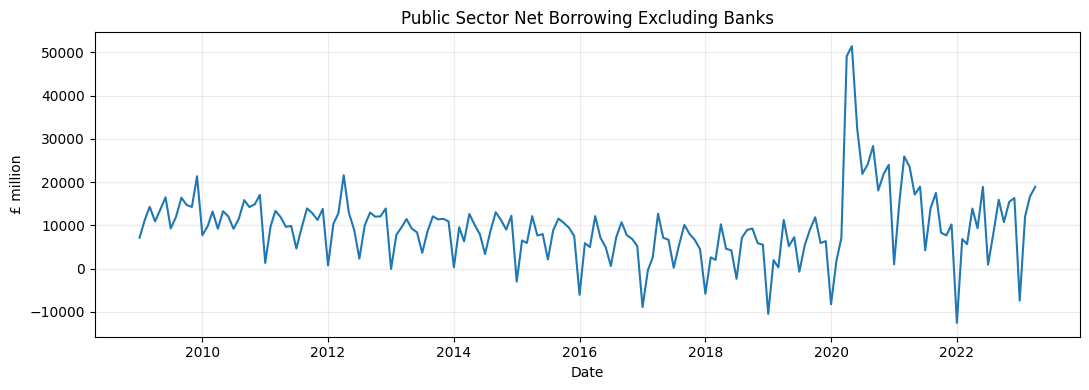

In [11]:
plt.figure(figsize=(11, 4))
plt.plot(master["date"], master["public_sector_net_borrowing_ex_banks_gbp_mn"])
plt.title("Public Sector Net Borrowing Excluding Banks")
plt.xlabel("Date")
plt.ylabel("£ million")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

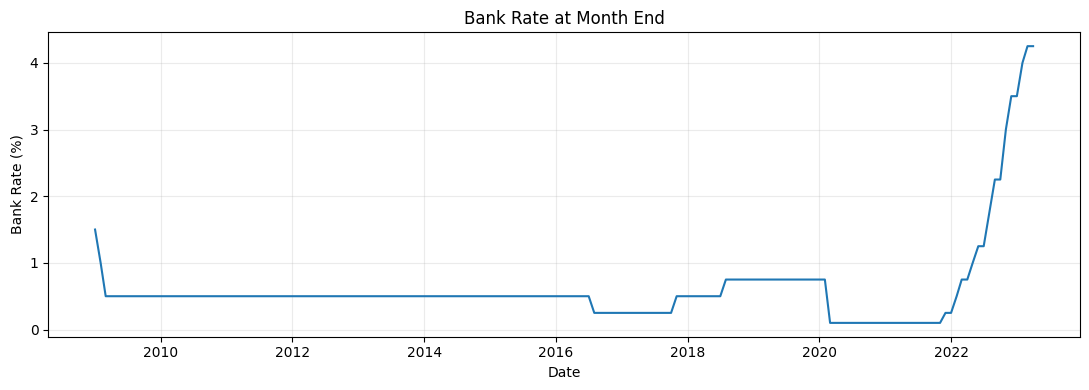

In [12]:
plt.figure(figsize=(11, 4))
plt.plot(master["date"], master["bank_rate_month_end_pct"])
plt.title("Bank Rate at Month End")
plt.xlabel("Date")
plt.ylabel("Bank Rate (%)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

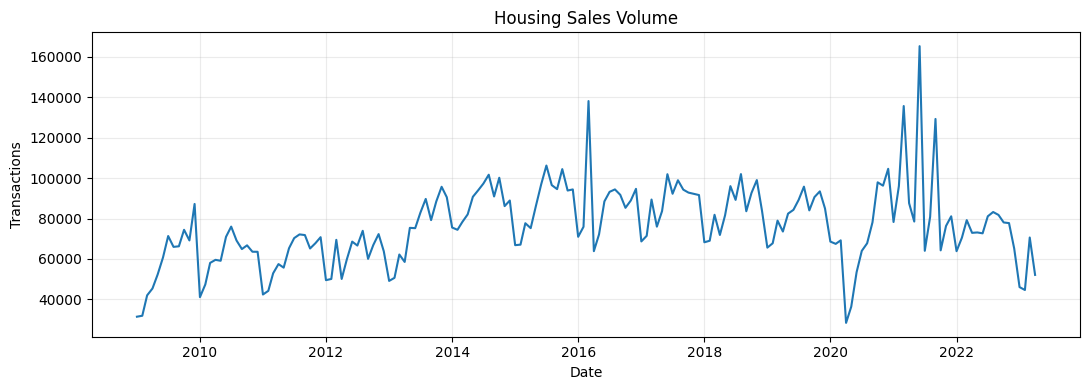

In [13]:
plt.figure(figsize=(11, 4))
plt.plot(master["date"], master["sales_volume"])
plt.title("Housing Sales Volume")
plt.xlabel("Date")
plt.ylabel("Transactions")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 7. Descriptive comparison across economic periods

The sample is divided into four broad periods for descriptive comparison only. These labels do not imply causality.

In [14]:
period_data = master.copy()

def assign_period(date):
    if date < pd.Timestamp("2013-01-01"):
        return "2009–2012"
    if date < pd.Timestamp("2020-01-01"):
        return "2013–2019"
    if date < pd.Timestamp("2022-01-01"):
        return "2020–2021"
    return "2022–Apr 2023"

period_data["period"] = period_data["date"].apply(assign_period)

period_summary = period_data.groupby("period", sort=False).agg(
    house_price_mean=("average_house_price_gbp", "mean"),
    annual_house_price_change_mean=("house_price_12m_change_pct", "mean"),
    sales_volume_mean=("sales_volume", "mean"),
    weekly_earnings_mean=("average_weekly_earnings_gbp", "mean"),
    unemployment_mean=("unemployment_rate_pct", "mean"),
    cpi_mean=("cpi_annual_rate_pct", "mean"),
    gdp_monthly_growth_mean=("gdp_monthly_growth_pct", "mean"),
    public_borrowing_mean=("public_sector_net_borrowing_ex_banks_gbp_mn", "mean"),
    bank_rate_mean=("bank_rate_month_end_pct", "mean"),
).round(2)

period_summary

,house_price_mean,annual_house_price_change_mean,sales_volume_mean,weekly_earnings_mean,unemployment_mean,cpi_mean,gdp_monthly_growth_mean,public_borrowing_mean,bank_rate_mean
period,,,,,,,,,
2009–2012,"166,989.170",-0.950,"60,935.750",448.440,7.900,3.200,0.090,"11,689.040",0.530
2013–2019,"207,091.910",4.610,"84,977.100",496.310,5.190,1.670,0.180,"6,214.630",0.510
2020–2021,"247,823.920",5.900,"82,054.080",563.170,4.530,1.710,0.130,"18,129.880",0.160
2022–Apr 2023,"284,670.240",8.600,"69,542.520",621.440,3.740,9.240,0.060,"9,334.750",2.160


## 8. Same-month correlations in the master dataset

These correlations describe historical co-movement with the **same-month house-price level**. Because house prices and some economic variables trend through time, a large coefficient does not by itself imply a strong forecasting relationship.

In [15]:
same_month_corr = (
    master.select_dtypes(include="number")
    .corr()["average_house_price_gbp"]
    .drop("average_house_price_gbp")
    .sort_values(ascending=False)
    .to_frame("correlation_with_same_month_house_price")
)
same_month_corr

,correlation_with_same_month_house_price
average_weekly_earnings_gbp,0.979
house_price_12m_change_pct,0.531
cpi_annual_rate_pct,0.428
bank_rate_month_end_pct,0.392
sales_volume,0.308
gdp_monthly_growth_pct,0.016
public_sector_net_borrowing_ex_banks_gbp_mn,0.012
unemployment_rate_pct,-0.889


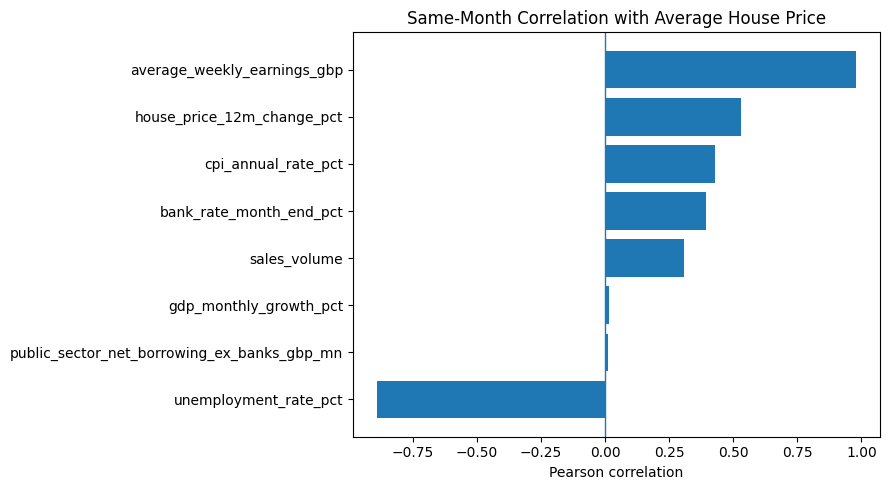

In [16]:
plot_corr = same_month_corr.sort_values("correlation_with_same_month_house_price")

plt.figure(figsize=(9, 5))
plt.barh(plot_corr.index, plot_corr["correlation_with_same_month_house_price"])
plt.axvline(0, linewidth=1)
plt.title("Same-Month Correlation with Average House Price")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

## 9. Forecast-feature correlations with next-month price level

The modelling table contains only information available no later than the forecast origin. Price lags and rolling price features are expected to be strongly related to the next-month level because house prices are persistent over time.

In [17]:
feature_columns = [
    c for c in model.columns
    if c not in ["forecast_origin", "target_date", "target_house_price_next_month_gbp"]
]

forecast_corr = (
    model[feature_columns + ["target_house_price_next_month_gbp"]]
    .corr()["target_house_price_next_month_gbp"]
    .drop("target_house_price_next_month_gbp")
    .sort_values(ascending=False)
    .to_frame("correlation_with_next_month_price")
)
forecast_corr

,correlation_with_next_month_price
house_price_lag_1m_gbp,0.998
house_price_rolling_3m_mean_gbp,0.998
house_price_lag_3m_gbp,0.996
house_price_rolling_12m_mean_gbp,0.993
house_price_lag_12m_gbp,0.983
average_weekly_earnings_lag_1m_gbp,0.977
cpi_annual_rate_lag_1m_pct,0.408
bank_rate_lag_1m_pct,0.385
sales_volume_lag_1m,0.245
public_sector_net_borrowing_lag_1m_gbp_mn,0.036


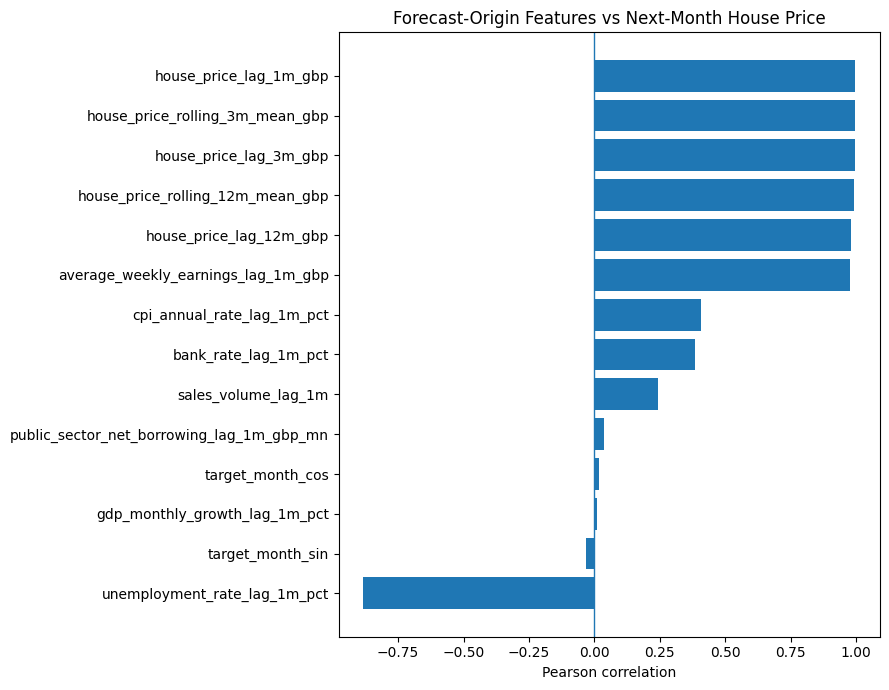

In [18]:
plot_corr = forecast_corr.sort_values("correlation_with_next_month_price")

plt.figure(figsize=(9, 7))
plt.barh(plot_corr.index, plot_corr["correlation_with_next_month_price"])
plt.axvline(0, linewidth=1)
plt.title("Forecast-Origin Features vs Next-Month House Price")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

## 10. Level prediction versus next-month price movement

A high correlation with the next-month **price level** can largely reflect persistence and long-run trend. To test whether features contain information about short-term movement, derive the percentage change from the latest observed house price to the next-month target.

This is an EDA diagnostic, not a replacement target for the project.

In [19]:
eda_model = model.copy()
eda_model["next_month_price_change_pct"] = (
    eda_model["target_house_price_next_month_gbp"] /
    eda_model["house_price_lag_1m_gbp"] - 1
) * 100

eda_model[[
    "forecast_origin",
    "target_date",
    "house_price_lag_1m_gbp",
    "target_house_price_next_month_gbp",
    "next_month_price_change_pct",
]].head()

,forecast_origin,target_date,house_price_lag_1m_gbp,target_house_price_next_month_gbp,next_month_price_change_pct
0,2009-12-01,2010-01-01,"168,081.609","167,468.930",-0.365
1,2010-01-01,2010-02-01,"167,468.930","167,887.682",0.250
2,2010-02-01,2010-03-01,"167,887.682","167,877.951",-0.006
3,2010-03-01,2010-04-01,"167,877.951","170,027.890",1.281
4,2010-04-01,2010-05-01,"170,027.890","170,845.925",0.481


In [20]:
change_corr = (
    eda_model[feature_columns + ["next_month_price_change_pct"]]
    .corr()["next_month_price_change_pct"]
    .drop("next_month_price_change_pct")
    .sort_values(ascending=False)
    .to_frame("correlation_with_next_month_change")
)
change_corr

,correlation_with_next_month_change
average_weekly_earnings_lag_1m_gbp,0.089
gdp_monthly_growth_lag_1m_pct,0.077
house_price_lag_3m_gbp,0.073
house_price_rolling_3m_mean_gbp,0.072
house_price_rolling_12m_mean_gbp,0.069
house_price_lag_12m_gbp,0.067
house_price_lag_1m_gbp,0.065
public_sector_net_borrowing_lag_1m_gbp_mn,0.049
target_month_sin,0.011
cpi_annual_rate_lag_1m_pct,-0.090


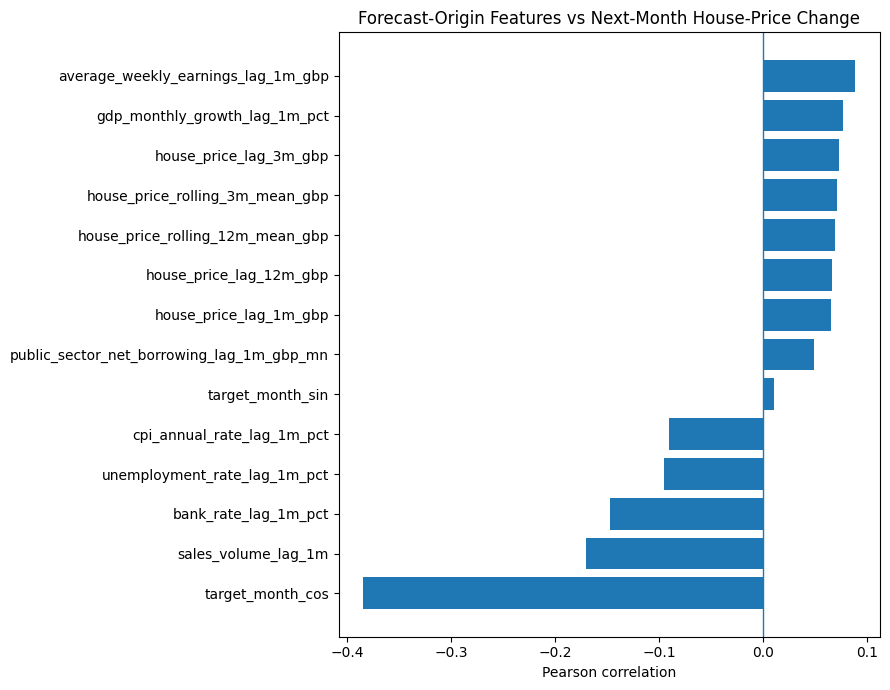

In [21]:
plot_corr = change_corr.sort_values("correlation_with_next_month_change")

plt.figure(figsize=(9, 7))
plt.barh(plot_corr.index, plot_corr["correlation_with_next_month_change"])
plt.axvline(0, linewidth=1)
plt.title("Forecast-Origin Features vs Next-Month House-Price Change")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

The comparison is important: a feature can be highly correlated with the future **price level** because both series trend over time, while showing little relationship with **month-to-month movement**. This is why the modelling stage will rely on chronological validation rather than correlation ranking alone.

## 11. Seasonality in next-month price movement

The modelling table includes sine/cosine month features. Here we inspect whether average month-to-month price movement differs by target month.

In [22]:
eda_model["target_month"] = eda_model["target_date"].dt.month

monthly_change = eda_model.groupby("target_month")["next_month_price_change_pct"].agg(
    mean="mean",
    median="median",
    std="std",
    count="count",
)
monthly_change

,mean,median,std,count
target_month,,,,
1,-0.151,-0.357,0.702,14
2,-0.056,-0.031,0.296,14
3,0.226,0.320,0.679,14
4,0.788,0.968,0.950,14
5,0.589,0.517,0.486,13
6,1.152,0.852,1.406,13
7,0.747,1.122,1.710,13
8,0.678,0.453,0.791,13
9,0.298,0.066,0.990,13


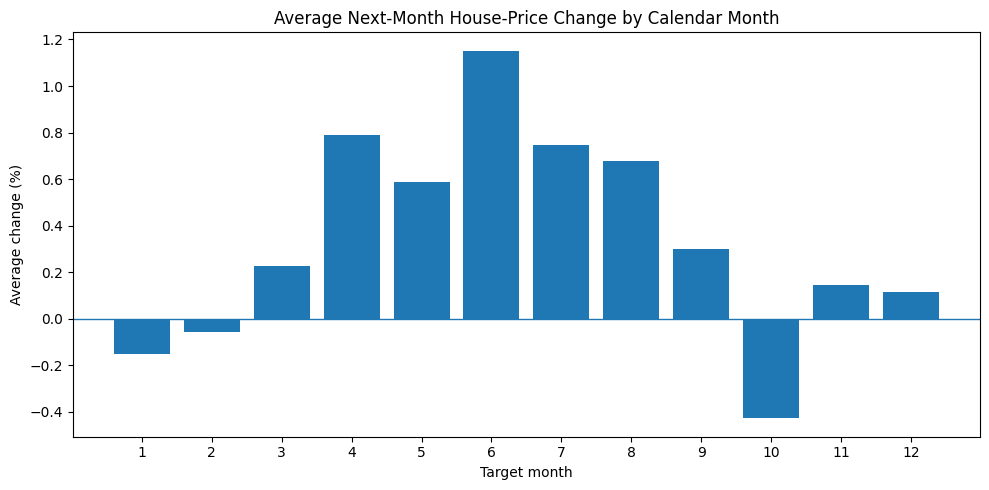

In [23]:
plt.figure(figsize=(10, 5))
plt.bar(monthly_change.index, monthly_change["mean"])
plt.axhline(0, linewidth=1)
plt.xticks(range(1, 13))
plt.title("Average Next-Month House-Price Change by Calendar Month")
plt.xlabel("Target month")
plt.ylabel("Average change (%)")
plt.tight_layout()
plt.show()

## 12. Feature redundancy and multicollinearity

Several price-history features intentionally describe similar information at different horizons. This can help nonlinear models, but it can make coefficient-based models unstable.

First, identify feature pairs with absolute Pearson correlation of at least 0.85.

In [24]:
feature_corr_matrix = model[feature_columns].corr().abs()

high_corr_pairs = []
for i, left in enumerate(feature_columns):
    for right in feature_columns[i + 1:]:
        value = feature_corr_matrix.loc[left, right]
        if value >= 0.85:
            high_corr_pairs.append((left, right, value))

high_corr_pairs = pd.DataFrame(
    high_corr_pairs,
    columns=["feature_1", "feature_2", "absolute_correlation"],
).sort_values("absolute_correlation", ascending=False)

high_corr_pairs.head(25)

,feature_1,feature_2,absolute_correlation
2,house_price_lag_1m_gbp,house_price_rolling_3m_mean_gbp,0.999
7,house_price_lag_3m_gbp,house_price_rolling_3m_mean_gbp,0.999
8,house_price_lag_3m_gbp,house_price_rolling_12m_mean_gbp,0.997
0,house_price_lag_1m_gbp,house_price_lag_3m_gbp,0.997
15,house_price_rolling_3m_mean_gbp,house_price_rolling_12m_mean_gbp,0.997
3,house_price_lag_1m_gbp,house_price_rolling_12m_mean_gbp,0.995
12,house_price_lag_12m_gbp,house_price_rolling_12m_mean_gbp,0.994
6,house_price_lag_3m_gbp,house_price_lag_12m_gbp,0.986
11,house_price_lag_12m_gbp,house_price_rolling_3m_mean_gbp,0.986
1,house_price_lag_1m_gbp,house_price_lag_12m_gbp,0.984


### Variance Inflation Factor (VIF)

VIF is shown as a diagnostic rather than a hard feature-selection rule. Very high values are expected for the multiple lagged and rolling house-price variables because they are derived from the same persistent time series.

In [25]:
vif_features = model[feature_columns].astype(float).copy()
vif_standardised = (vif_features - vif_features.mean()) / vif_features.std(ddof=0)

vif_table = pd.DataFrame({
    "feature": vif_standardised.columns,
    "VIF": [
        variance_inflation_factor(vif_standardised.values, i)
        for i in range(vif_standardised.shape[1])
    ],
}).sort_values("VIF", ascending=False)

vif_table

,feature,VIF
3,house_price_rolling_3m_mean_gbp,"4,894.662"
4,house_price_rolling_12m_mean_gbp,"1,762.499"
0,house_price_lag_1m_gbp,"1,664.995"
1,house_price_lag_3m_gbp,"1,283.221"
2,house_price_lag_12m_gbp,322.914
6,average_weekly_earnings_lag_1m_gbp,63.642
7,unemployment_rate_lag_1m_pct,23.879
8,cpi_annual_rate_lag_1m_pct,5.031
11,bank_rate_lag_1m_pct,2.875
12,target_month_sin,2.739


## 13. Outlier and shock diagnostics

Large movements in GDP growth and public borrowing can represent genuine economic shocks rather than bad data. The purpose here is to identify the most extreme months and preserve them for time-aware model evaluation.

In [26]:
shock_columns = [
    "house_price_12m_change_pct",
    "sales_volume",
    "unemployment_rate_pct",
    "cpi_annual_rate_pct",
    "gdp_monthly_growth_pct",
    "public_sector_net_borrowing_ex_banks_gbp_mn",
    "bank_rate_month_end_pct",
]

extremes = []
for column in shock_columns:
    min_row = master.loc[master[column].idxmin(), ["date", column]]
    max_row = master.loc[master[column].idxmax(), ["date", column]]
    extremes.append({
        "variable": column,
        "minimum": min_row[column],
        "minimum_date": min_row["date"].date(),
        "maximum": max_row[column],
        "maximum_date": max_row["date"].date(),
    })

pd.DataFrame(extremes)

,variable,minimum,minimum_date,maximum,maximum_date
0,house_price_12m_change_pct,-15.619,2009-02-01,14.232,2022-07-01
1,sales_volume,"28,356.333",2020-04-01,"165,290.000",2021-06-01
2,unemployment_rate_pct,3.500,2022-07-01,8.500,2011-10-01
3,cpi_annual_rate_pct,-0.100,2015-04-01,11.100,2022-10-01
4,gdp_monthly_growth_pct,-20.900,2020-04-01,9.000,2020-06-01
5,public_sector_net_borrowing_ex_banks_gbp_mn,"-12,570.000",2022-01-01,"51,405.000",2020-05-01
6,bank_rate_month_end_pct,0.100,2020-03-01,4.250,2023-03-01


## 14. EDA conclusions for the modelling stage

The exploratory analysis supports the following modelling decisions:

1. **Chronological validation is essential.** House prices and several predictors are strongly trended, so random splitting could produce overly optimistic performance.
2. **Lagged house-price information is likely to be the strongest baseline signal.** The next-month level is highly persistent.
3. **High level correlations should not be treated as causal or as sufficient evidence of predictive value.** Trending macroeconomic variables can appear strongly related to a trending target.
4. **Short-term price movement is harder to explain than the price level.** Correlations with next-month percentage movement are much weaker.
5. **Seasonality is worth retaining.** Month-of-year patterns are visible in average monthly price changes, supporting the sine/cosine calendar features.
6. **Multicollinearity is substantial among lagged and rolling price features.** Linear models should use regularisation and careful feature selection.
7. **Economic shock observations should be retained.** They represent real market regimes and are important tests of model robustness.
8. **Model comparison must use an untouched chronological holdout.** Feature engineering, scaling, model selection and hyperparameter tuning should be confined to the training period.

The next notebook will use these findings to establish strong baselines and compare machine-learning models under time-aware validation.